In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os , shutil
import cv2
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
import tensorflow as tf
import imutils
from tqdm import tqdm

## 1) DataSet Loading

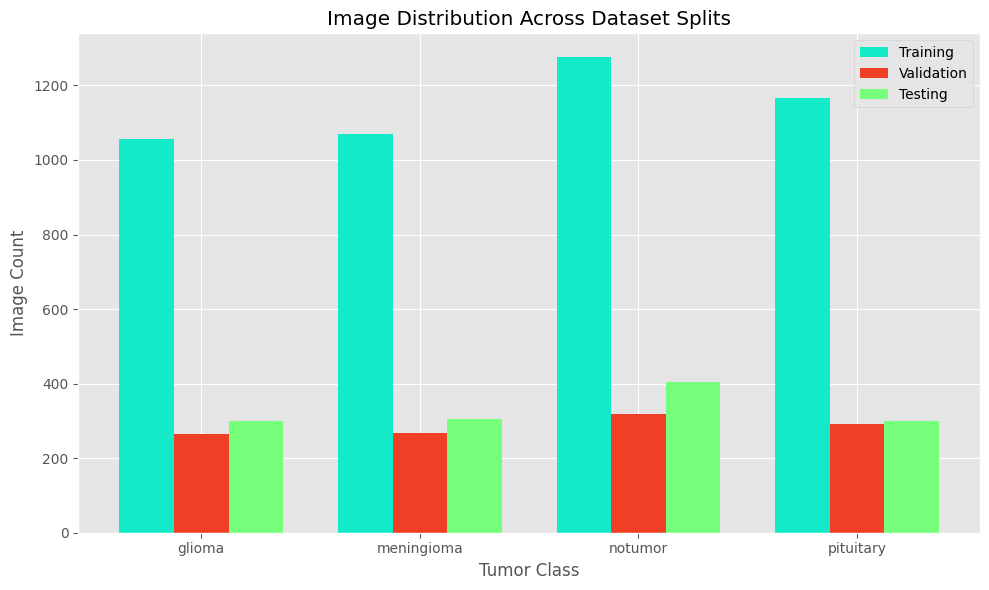

In [3]:
# Define your base dataset directories
base_dirs = {
    'Training': 'Brain Tumor\Training',
    'Validation': 'Brain Tumor\Validation',
    'Testing': 'Brain Tumor\Testing'
}

# To store counts
data_counts = {}

# Traverse each set and its class folders
for set_name, path in base_dirs.items():
    class_counts = {}
    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
    data_counts[set_name] = class_counts

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
class_labels = list(next(iter(data_counts.values())).keys())

# Bar width and positions
x = range(len(class_labels))
bar_width = 0.25
colors = ['#13EAC9', '#EF4026', '#76FF7B']  # Matching your color palette

# Plot bars for each set
for i, (set_name, class_data) in enumerate(data_counts.items()):
    heights = [class_data.get(label, 0) for label in class_labels]
    ax.bar([p + i * bar_width for p in x], heights, width=bar_width, label=set_name, color=colors[i])

# Labeling
ax.set_xlabel('Tumor Class')
ax.set_ylabel('Image Count')
ax.set_title('Image Distribution Across Dataset Splits')
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(class_labels)
ax.legend()

plt.tight_layout()
plt.show()


# 2) Data Augmentation

In [77]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# def augment_training_images(base_dir, n_gen_sample=2):
#     classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
#     data_gen = ImageDataGenerator(
#         rotation_range=10,
#         width_shift_range=0.1,
#         height_shift_range=0.1,
#         shear_range=0.1,
#         brightness_range=(0.3, 1.0),
#         horizontal_flip=True,
#         vertical_flip=True,
#         fill_mode='nearest'
#     )

#     for class_name in classes:
#         class_path = os.path.join(base_dir, class_name)
#         for filename in os.listdir(class_path):
#             if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
#                 continue
#             if filename.startswith('aug_'):  # skip already augmented images
#                 continue

#             img_path = os.path.join(class_path, filename)
#             image = cv2.imread(img_path)
#             if image is None:
#                 continue

#             image = image.reshape((1,) + image.shape)
#             save_prefix = 'aug_' + filename.split('.')[0]

#             i = 0
#             for batch in data_gen.flow(x=image, batch_size=1,
#                                        save_to_dir=class_path,
#                                        save_prefix=save_prefix,
#                                        save_format='jpg'):
#                 i += 1
#                 if i >= n_gen_sample:
#                     break

# # Example usage
# augment_training_images('Brain Tumor/Training', n_gen_sample=1)



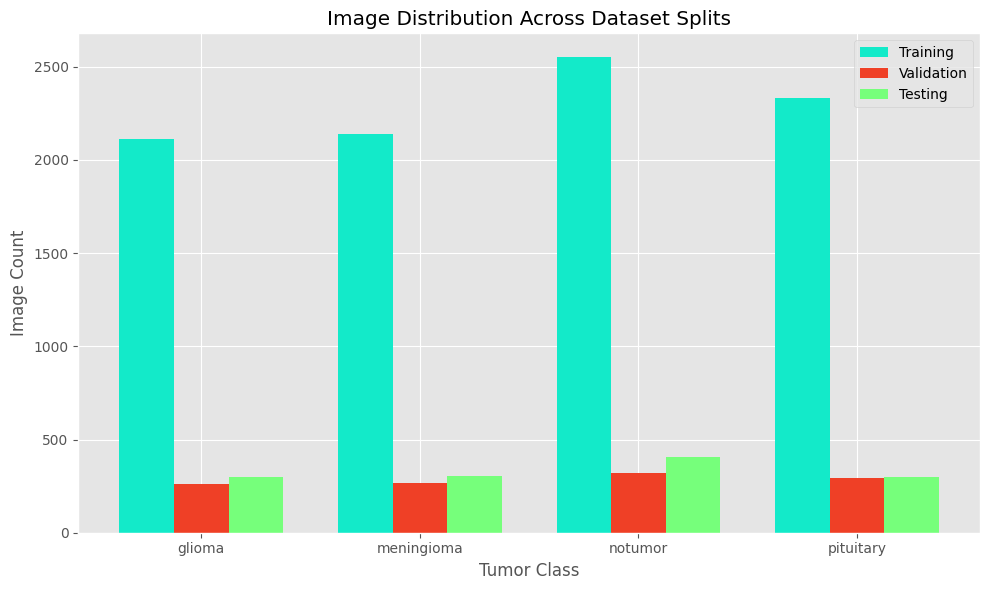

In [78]:
# Define your base dataset directories
base_dirs = {
    'Training': 'Brain Tumor\Training',
    'Validation': 'Brain Tumor\Validation',
    'Testing': 'Brain Tumor\Testing'
}

# To store counts
data_counts = {}

# Traverse each set and its class folders
for set_name, path in base_dirs.items():
    class_counts = {}
    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            class_counts[class_name] = count
    data_counts[set_name] = class_counts

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
class_labels = list(next(iter(data_counts.values())).keys())

# Bar width and positions
x = range(len(class_labels))
bar_width = 0.25
colors = ['#13EAC9', '#EF4026', '#76FF7B']  # Matching your color palette

# Plot bars for each set
for i, (set_name, class_data) in enumerate(data_counts.items()):
    heights = [class_data.get(label, 0) for label in class_labels]
    ax.bar([p + i * bar_width for p in x], heights, width=bar_width, label=set_name, color=colors[i])

# Labeling
ax.set_xlabel('Tumor Class')
ax.set_ylabel('Image Count')
ax.set_title('Image Distribution Across Dataset Splits')
ax.set_xticks([p + bar_width for p in x])
ax.set_xticklabels(class_labels)
ax.legend()

plt.tight_layout()
plt.show()


# 3) Data Preprocessing

In [79]:
def crop(image , plot = False):
    gray = cv2.cvtColor(image , cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray , (5,5) , 0)

    thresh = cv2.threshold(gray , 45 , 255 , cv2.THRESH_BINARY)[1]
    cv2.erode(thresh , None , iterations = 2)
    cv2.dilate(thresh , None , iterations = 2)    

    cnts = cv2.findContours(thresh.copy() , cv2.RETR_EXTERNAL , cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts , key = cv2.contourArea)

    extLeft = tuple(c[c[:,:,0].argmin()][0])
    extRight = tuple(c[c[:,:,0].argmax()][0])
    extTop = tuple(c[c[:,:,1].argmin()][0])
    extBot = tuple(c[c[:,:,1].argmax()][0])

    new_image = image[extTop[1]:extBot[1] , extLeft[0]:extRight[0]]

    if plot:
        plt.figure()
        plt.subplot(1 , 2 , 1)
        plt.imshow(image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Original Image')

        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Cropped Image')
        plt.show()
    
    return new_image

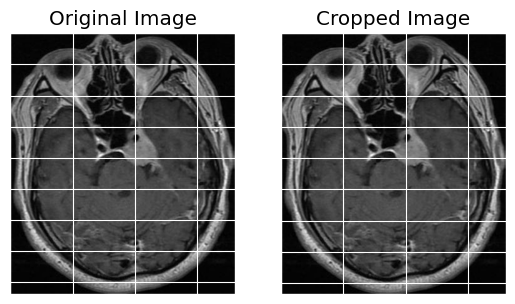

array([[[5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        ...,
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]],

       [[5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        ...,
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]],

       [[5, 5, 5],
        [5, 5, 5],
        [5, 5, 5],
        ...,
        [5, 5, 5],
        [5, 5, 5],
        [5, 5, 5]],

       ...,

       [[4, 4, 4],
        [4, 4, 4],
        [4, 4, 4],
        ...,
        [4, 4, 4],
        [4, 4, 4],
        [4, 4, 4]],

       [[4, 4, 4],
        [4, 4, 4],
        [4, 4, 4],
        ...,
        [4, 4, 4],
        [4, 4, 4],
        [4, 4, 4]],

       [[4, 4, 4],
        [4, 4, 4],
        [4, 4, 4],
        ...,
        [4, 4, 4],
        [4, 4, 4],
        [4, 4, 4]]], dtype=uint8)

In [81]:
img = cv2.imread(r'Brain Tumor\Training\meningioma\aug_Tr-me_0280_0_2470.jpg')
crop(img , True)

In [82]:
# --- Folder Paths ---
base_dir = 'Brain Tumor'
sub_dirs = ['Training', 'Validation', 'Testing']
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# --- Apply Crop to All Images ---
for sub in sub_dirs:
    for cls in classes:
        folder_path = os.path.join(base_dir, sub, cls)
        print(f"Processing: {folder_path}")

        for filename in tqdm(os.listdir(folder_path)):
            if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            cropped = crop(img)

            if cropped is not None:
                cv2.imwrite(img_path, cropped)


Processing: Brain Tumor\Training\glioma


100%|██████████| 2114/2114 [00:25<00:00, 81.34it/s] 


Processing: Brain Tumor\Training\meningioma


100%|██████████| 2142/2142 [00:30<00:00, 70.48it/s] 


Processing: Brain Tumor\Training\notumor


...

100%|██████████| 306/306 [00:01<00:00, 162.20it/s]


Processing: Brain Tumor\Testing\notumor


100%|██████████| 405/405 [00:01<00:00, 242.62it/s]


Processing: Brain Tumor\Testing\pituitary


100%|██████████| 300/300 [00:02<00:00, 138.30it/s]


In [83]:
data_gen = ImageDataGenerator(
    rescale=1./255
)

# Update the paths according to your actual folder structure
train_generator = data_gen.flow_from_directory(
    'Brain Tumor/Training/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    color_mode='rgb',
    seed=42
)

valid_generator = data_gen.flow_from_directory(
    'Brain Tumor/Validation/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    color_mode='rgb',
    seed=42
)

test_generator = data_gen.flow_from_directory(
    'Brain Tumor/Testing/',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb',
    seed=42
)

Found 9140 images belonging to 4 classes.
Found 1142 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [84]:
class_labels = train_generator.class_indices
class_name = {value: key for (key,value) in class_labels.items()}

In [85]:
class_name

{0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}

# <span style="color:aquamarine"> Model Training - MobileNetV3 </span>


In [86]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout , BatchNormalization , GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV3Large  
from tensorflow.keras.optimizers import SGD , Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
# Load MobileNetV3 Large
base_model = MobileNetV3Large(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Freeze base model layers
base_model.trainable = False  

# Custom fully connected layers
x = GlobalAveragePooling2D()(base_model.output)  # Use GAP instead of Flatten
x = Dense(1024, activation='relu', kernel_initializer='he_normal')(x)  
x = BatchNormalization()(x)  
x = Dropout(0.5)(x)  

x = Dense(512, activation='relu', kernel_initializer='he_normal')(x)  
x = BatchNormalization()(x)  
x = Dropout(0.5)(x)  

output = Dense(4, activation='softmax')(x)  # Output layer

# Create the final model
model_01 = Model(inputs=base_model.input, outputs=output)

In [87]:
filepath = 'model.h5'  # This is the path where your model's weights will be stored.

# Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=4, mode='min', verbose=1, restore_best_weights=True)

# Model checkpoint to save the best model based on validation loss
cp = ModelCheckpoint(filepath, monitor='val_loss', save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Reduce learning rate when validation accuracy stops improving
lrr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3, min_lr=1e-6, verbose=1)

In [88]:
adam = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
model_01.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy', 'Precision', 'Recall'])

In [90]:
history_01 = model_01.fit(
    train_generator,
    steps_per_epoch=len(train_generator), 
    epochs=10,  # Increase epochs for better learning
    callbacks=[es, cp, lrr],  
    validation_data=valid_generator,  
    validation_steps=len(valid_generator),  
    verbose=1  # Ensures you see training progress
)

Epoch 1/10
286/286 [==============================] - ETA: 0s - loss: 1.3438 - accuracy: 0.5025 - precision: 0.5397 - recall: 0.4351
Epoch 1: val_loss improved from inf to 1.11656, saving model to model.h5


c:\Users\Mustafa Husain\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


286/286 [==============================] - 113s 391ms/step - loss: 1.3438 - accuracy: 0.5025 - precision: 0.5397 - recall: 0.4351 - val_loss: 1.1166 - val_accuracy: 0.4974 - val_precision: 0.7107 - val_recall: 0.2259 - lr: 1.0000e-04
Epoch 2/10
286/286 [==============================] - ETA: 0s - loss: 1.1658 - accuracy: 0.5478 - precision: 0.5906 - recall: 0.4774
Epoch 2: val_loss improved from 1.11656 to 1.11330, saving model to model.h5
286/286 [==============================] - 65s 229ms/step - loss: 1.1658 - accuracy: 0.5478 - precision: 0.5906 - recall: 0.4774 - val_loss: 1.1133 - val_accuracy: 0.5350 - val_precision: 0.6239 - val_recall: 0.3616 - lr: 1.0000e-04
Epoch 3/10
286/286 [==============================] - ETA: 0s - loss: 1.0876 - accuracy: 0.5632 - precision: 0.6107 - recall: 0.4942
Epoch 3: val_loss did not improve from 1.11330
286/286 [==============================] - 62s 216ms/step - loss: 1.0876 - accuracy: 0.5632 - precision: 0.6107 - recall: 0.4942 - val_loss: 1.

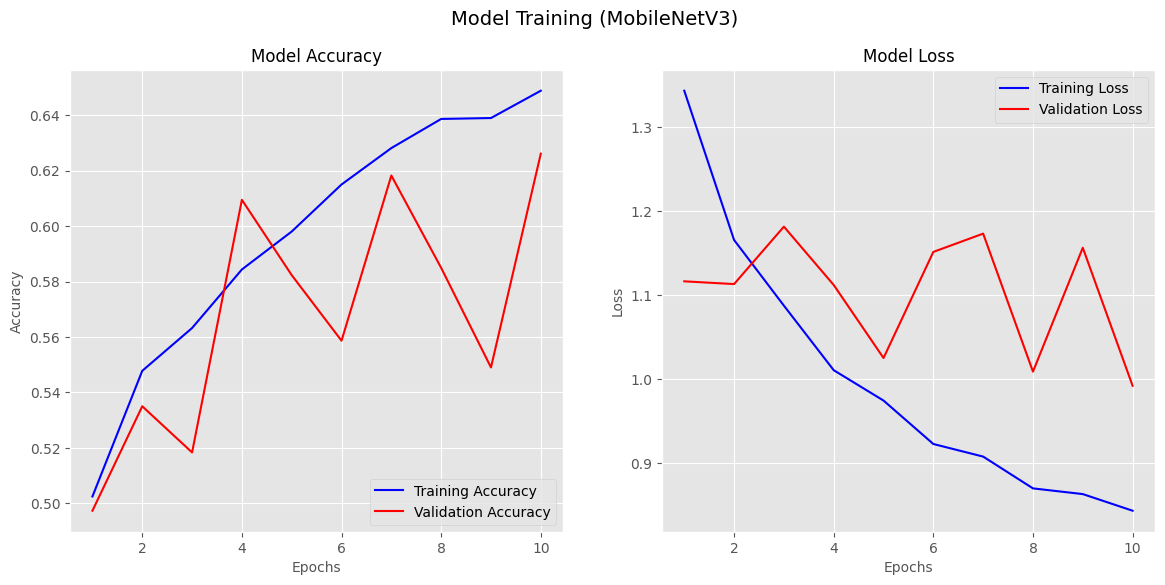

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Training (MobileNetV3)", fontsize=14)

epochs_list = range(1, len(history_01.history['accuracy']) + 1)

# Accuracy Plot
axes[0].plot(epochs_list, history_01.history['accuracy'], 'b-', label='Training Accuracy')
axes[0].plot(epochs_list, history_01.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Accuracy', fontsize=10)
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Loss Plot
axes[1].plot(epochs_list, history_01.history['loss'], 'b-', label='Training Loss')
axes[1].plot(epochs_list, history_01.history['val_loss'], 'r-', label='Validation Loss')
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xlabel('Epochs', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend(loc='upper right')
axes[1].grid(True)

In [95]:
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_01.save_weights(filepath="model_weights/mobilenetv3_01.weights.h5", overwrite=True)
model_01.load_weights("model_weights/mobilenetv3_01.weights.h5")
mobilenet_val_eval = model_01.evaluate(valid_generator)
mobilenet_test_eval = model_01.evaluate(test_generator)

41/41 [==============================] - 8s 185ms/step - loss: 0.7933 - accuracy: 0.7010 - precision: 0.7500 - recall: 0.5973


In [96]:
print(f'Validation Loss: {mobilenet_val_eval[0]}')
print(f'Validation Acc: {mobilenet_val_eval[1]}')
print(f'Testing Loss: {mobilenet_test_eval[0]}')
print(f'Testing Acc: {mobilenet_test_eval[1]}')

Validation Loss: 0.9920325875282288
Validation Acc: 0.6260945796966553
Testing Loss: 0.7933440804481506
Testing Acc: 0.7009916305541992
